In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
import cartopy.feature as cfeature

import seaborn as sns
import matplotlib.colors as cols
from mpl_toolkits.basemap import Basemap

In [2]:
iceyes = np.load('/home/dell/iHESPdata/UVEL/SALTtime333.npy')

In [3]:
iceyes.shape

(3000,)

In [4]:
ee = iceyes.reshape((250,12))
ee1 = np.nanmean(ee,axis=1)

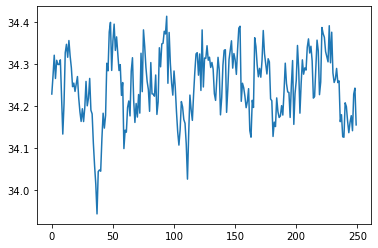

In [5]:
plt.plot(ee1)

In [6]:
arr = ee1
window_size = 5

i = 0
# Initialize an empty list to store moving averages
moving_averages = []

# Loop through the array t o
#consider every window of size 3
while i < len(arr) - window_size + 1:

    # Calculate the average of current window
    window_average = round(np.sum(arr[
      i:i+window_size]) / window_size, 2)
    
    # Store the average of current
    # window in moving average list
    moving_averages.append(window_average)
    
    # Shift window to right by one position
    i += 1

In [7]:
WSPsmall = np.load('/home/dell/iHESPplot/iceplot/smallMRP.npy')
WSPbigger = np.load('/home/dell/iHESPplot/iceplot/smallWSP.npy')

In [8]:
denall = np.load('/media/dell/Elements/new/seperatesigma1copy/densityall.npy')
denave = np.load('/media/dell/Elements/new/seperatesigma1copy/densityrunningmean.npy')

In [9]:
pwd

'/home/dell/iHESPplot/Paper3'

findfont: Font family ['Cambria'] not found. Falling back to DejaVu Sans.


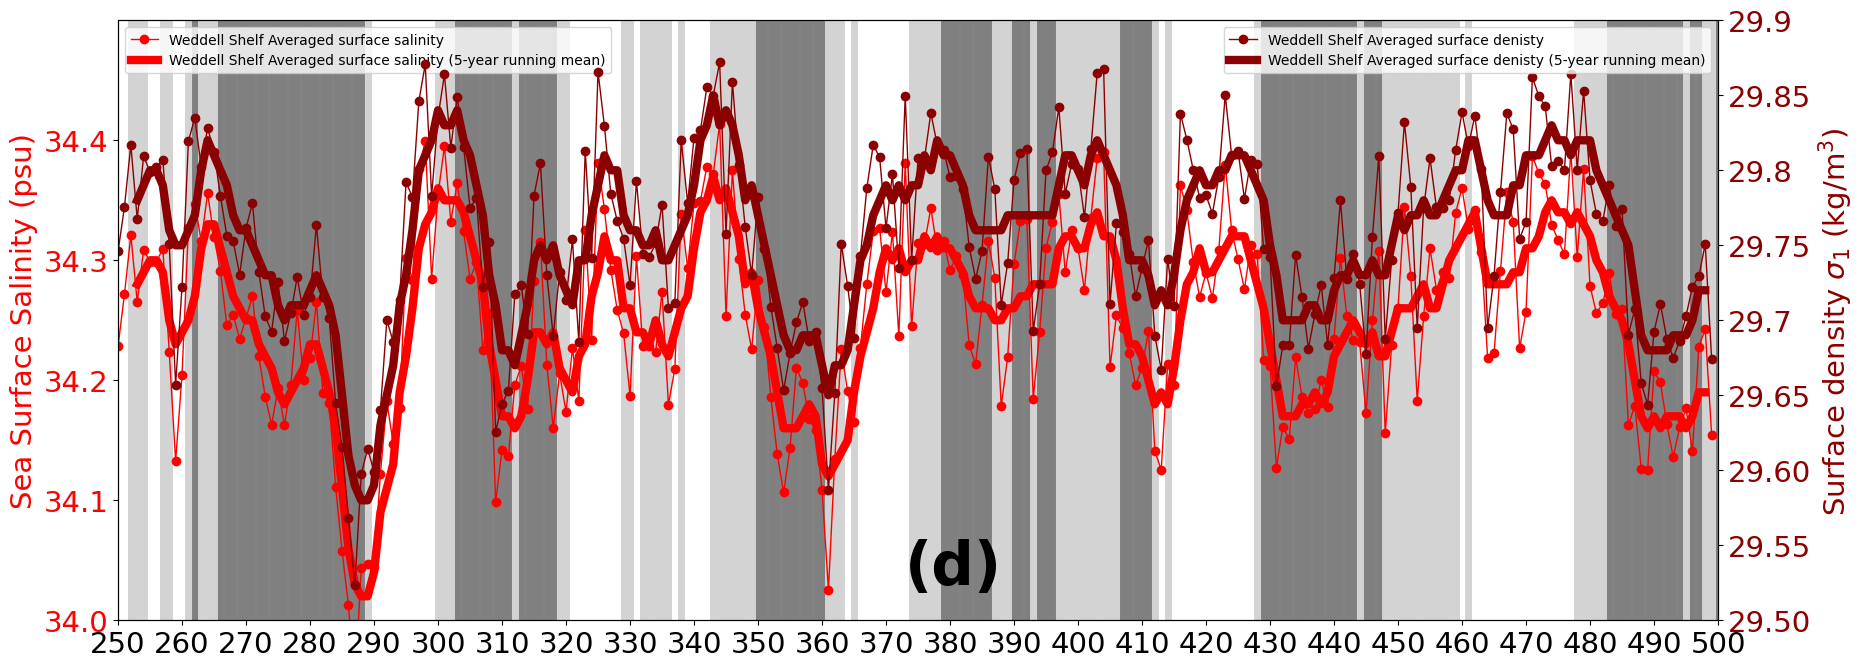

In [10]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = {'fontname':'Cambria', 'size':'21'}
################################################################
################################################################
t = np.arange(3,249,1)
ax1 = fig.add_axes([0.1, 0.9, 0.8, 0.3],
                   xticklabels=[])
ax1.plot(ee1,color='red',marker='o',linewidth=1,label='Weddell Shelf Averaged surface salinity')

ax1.plot(t,moving_averages,color='red',linewidth=6,label='Weddell Shelf Averaged surface salinity (5-year running mean)')
plt.legend(loc='upper left')#,fontsize='xx-large')
#plt.legend()
plt.vlines(WSPbigger, 34.0,34.5, linestyles="solid", colors="grey" ,linewidth=5)
plt.vlines(WSPsmall, 34.0,34.5, linestyles="solid", colors="lightgrey" ,linewidth=5)

plt.axis("tight")
plt.yticks(np.arange(34.0,34.5,0.1), ['34.0','34.1','34.2','34.3','34.4'],**my_font,color='red')
plt.ylabel('Sea Surface Salinity (psu)',**my_font,color='red')
#plt.title('Weddell Sea Shelf Sea Surface Salinity Time series',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
ax1.set(ylim=(34.0,34.5),xlim=(0, 250))
#plt.savefig("DSWoverflow.png",bbox_inches='tight')

ax2 = ax1.twinx()
ax2.plot(denall,color='darkred',marker='o',linewidth=1,label='Weddell Shelf Averaged surface denisty')

ax2.plot(t,denave,color='darkred',linewidth=6,label='Weddell Shelf Averaged surface denisty (5-year running mean)')
plt.legend(loc='upper right')#,fontsize='xx-large')
plt.yticks(np.arange(29.50,29.95,0.05), ['29.50','29.55','29.60','29.65','29.7','29.75','29.8','29.85','29.9'],**my_font,color='darkred')
plt.ylabel('Surface density $\sigma$$_1$ (kg/m$^3$) ',**my_font,color='darkred')
#plt.legend()
#ax2.set(ylim=(0, 8),xlim=(0, 250))

ax1.text(123, 34.03, '(d)',size=43, weight='bold',color='black')

plt.savefig("FigSS3d.png",bbox_inches='tight')
